# Notebook 07 — Question 5a: Genre Label vs Content

**Reviewer question:** Are the neural differences between Haiku and Senryu really about content (nature vs emotion), or just the genre label?

**Strategy:** Three converging item-level analyses:
1. **Top/bottom quartile comparison** — do high-quality poems converge neurally across genres, or stay distinct?
2. **Rating-profile clustering** — do poems cluster by content rather than genre?
3. **RSA** — does neural similarity track evaluative similarity across poems?

**Key data note:** Poem→epoch mapping is recovered via Hungarian matching on 5D rating fingerprints (verified perfect match, cost=0 for all participants).

**Paths assume notebook lives alongside the original notebook 06, in the same directory.**

In [1]:
import joblib
import re
import shap
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ────────────────────────────────────────────────────────────
TEAL_DARK  = '#1A5F5F'
TEAL_BASE  = '#3DA5A5'
TEAL_LIGHT = '#6EC4C4'
TEAL_PALE  = '#B5E0E0'
SAND_DARK  = '#8B7355'
SAND_MED   = '#C4A77D'
SAND_BASE  = '#D4C4A8'
SAND_LIGHT = '#E8DFD0'
SAND_PALE  = '#F5F1EB'
CORAL_BASE = '#E8927A'
CORAL_MED  = '#E07B5F'
CORAL_DARK = '#C75D4A'
BG         = '#FAFAF8'
TEXT_DARK  = '#2C2C2C'
TEXT_MED   = '#5A5A5A'

STIM_COLORS = {'Haiku': TEAL_BASE, 'Senryu': SAND_DARK}

print('Imports OK')

Imports OK


## 1. Load Data and Build Poem-Level Ratings

In [26]:
# ── Load files ────────────────────────────────────────────────────────────────
# Adjust paths as needed
TRIAL_ORDER_PATH = 'data/results_trial_order_all_participants.csv'
TARGET_PATH      = 'data/target.csv'
FEATURES_PATH    = 'data/mean_power_morlet_wavelets_with_delta_theta.csv'
MODELS_DIR       = 'models/'

trial_order = pd.read_csv(TRIAL_ORDER_PATH)
target      = pd.read_csv(TARGET_PATH)
df_feat     = pd.read_csv(FEATURES_PATH)

# Reconstruct subject_name and epoch as in notebook 06
target['subject_name'] = ['P10'+str(x) if len(str(x))<=1 else 'P1'+str(x) for x in target['Participant']]
target['epoch']        = target.groupby('subject_name').cumcount() + 1

print('trial_order:', trial_order.shape)
print('target:     ', target.shape)
print('features:   ', df_feat.shape)

trial_order: (10710, 11)
target:      (10710, 10)
features:    (963810, 6)


In [27]:
# ── Fix duplicate poem labels (4 poems share first-line labels across different poems) ──
# Use PoemName (full 3-line text) as the unique identifier
duplicates = ['insert tab', 'measure twice', 'new law', 'light']
trial_order['poem_id'] = trial_order['PoemName']  # full text is unique

# Sanity check
n_unique = trial_order.groupby('PoemType')['poem_id'].nunique()
print('Unique poems per type (should be 70 each):')
print(n_unique)

Unique poems per type (should be 70 each):
PoemType
Control    70
Haiku      70
Senryu     70
Name: poem_id, dtype: int64


In [28]:
# ── Exclude 4 bad-data participants (same as notebook 06) ──────────────────────
EXCLUDE = ['P105', 'P141', 'P142', 'P146']
trial_order_clean = trial_order[~trial_order['participant'].isin(EXCLUDE)].copy()
print(f'Participants retained: {trial_order_clean["participant"].nunique()}')

# ── Poem-level mean ratings (all 5 dimensions) ─────────────────────────────────
# Using trial_order directly — no need to go through target.csv for ratings
RATING_COLS = ['AA', 'Imagery', 'Moved', 'Originality', 'Creativity']
RATING_LABELS = ['Aesthetic Appeal', 'Vivid Imagery', 'Being Moved', 'Originality', 'Creativity']

poem_ratings = (
    trial_order_clean
    .groupby(['PoemType', 'poem_id'])[RATING_COLS]
    .mean()
    .reset_index()
)

# Focus on poetry only (exclude Control for most analyses)
poem_ratings_poetry = poem_ratings[poem_ratings['PoemType'].isin(['Haiku', 'Senryu'])].copy()
poem_ratings_poetry['Genre'] = poem_ratings_poetry['PoemType']  # already full names

print(f'Poems included: {len(poem_ratings_poetry)} ({poem_ratings_poetry.groupby("Genre").size().to_dict()})')
poem_ratings_poetry.head()

Participants retained: 47
Poems included: 140 ({'Haiku': 70, 'Senryu': 70})


,PoemType,poem_id,AA,Imagery,Moved,Originality,Creativity,Genre
70,Haiku,All Saints morning\na path\nof trodden leaves,4.468085,4.893617,3.978723,4.000000,3.957447,Haiku
71,Haiku,All Souls Day...\nmy name called\nfrom the fro...,4.617021,4.510638,4.319149,4.510638,4.680851,Haiku
72,Haiku,Indian summer\na spent salmon\nwashes ashore,4.659574,5.297872,4.085106,4.617021,4.574468,Haiku
73,Haiku,Mars landing\ncardboard softens\nthe subway grate,3.893617,4.276596,3.297872,4.361702,4.021277,Haiku
74,Haiku,Navajo moon\nthe coyote call\nnot a coyote,4.553191,4.574468,3.489362,4.382979,4.340426,Haiku


## 2. Recover Poem→Epoch Mapping (Hungarian Matching)

Target.csv epochs are sorted by PoemType within participant; trial_order gives the actual presentation order.
We recover the mapping using perfect 5D rating fingerprinting (verified zero-cost match for all participants).

In [29]:
def recover_poem_epoch_mapping(trial_order_clean, target, exclude=EXCLUDE):
    """
    For each participant × PoemType, use Hungarian matching on all 5 ratings
    to map trial_number → epoch (position in target.csv sorted order).
    Returns a DataFrame: participant, trial_number, poem_id, PoemType (full), PoemType_letter, epoch
    """
    target_clean = target[~target['subject_name'].isin(exclude)].copy()
    
    ptype_to_letter = {'Haiku': 'H', 'Senryu': 'S', 'Control': 'C'}
    records = []
    total_cost = 0
    
    for participant in trial_order_clean['participant'].unique():
        for ptype_full, ptype_letter in ptype_to_letter.items():
            
            # trial_order uses full names
            to_sub = (
                trial_order_clean[
                    (trial_order_clean['participant'] == participant) &
                    (trial_order_clean['PoemType'] == ptype_full)
                ]
                .sort_values('trial_number')
                .reset_index(drop=True)
            )
            
            # target.csv uses letter codes
            tg_sub = (
                target_clean[
                    (target_clean['subject_name'] == participant) &
                    (target_clean['PoemType'] == ptype_letter)
                ]
                .sort_values('epoch')
                .reset_index(drop=True)
            )
            
            if len(to_sub) == 0 or len(tg_sub) == 0:
                continue
            
            # Build cost matrix
            to_ratings = to_sub[['AA','Imagery','Moved','Originality','Creativity']].values
            tg_ratings = tg_sub[
                ['Aesthetic_Appeal','Vivid_Imagery','Moved','Originality','Creativity']
            ].values
            
            cost = np.sum(
                np.abs(to_ratings[:, None, :] - tg_ratings[None, :, :]),
                axis=2
            )
            row_ind, col_ind = linear_sum_assignment(cost)
            total_cost += cost[row_ind, col_ind].sum()
            
            for r, c in zip(row_ind, col_ind):
                records.append({
                    'participant':    participant,
                    'trial_number':   to_sub.loc[r, 'trial_number'],
                    'poem_id':        to_sub.loc[r, 'poem_id'],
                    'PoemType':       ptype_full,    # full name — matches trial_order
                    'PoemType_letter': ptype_letter, # letter code — matches target.csv
                    'epoch':          tg_sub.loc[c, 'epoch'],
                })
    
    mapping = pd.DataFrame(records)
    print(f'Total matching cost across all participants × types: {total_cost}')
    print(f'  (0 = perfect recovery of poem→epoch for every trial)')
    return mapping

poem_epoch_map = recover_poem_epoch_mapping(trial_order_clean, target)
print(f'\nMapping table shape: {poem_epoch_map.shape}')
poem_epoch_map.head(10)

Total matching cost across all participants × types: 0
  (0 = perfect recovery of poem→epoch for every trial)

Mapping table shape: (9870, 6)


,participant,trial_number,poem_id,PoemType,PoemType_letter,epoch
0,P101,4,whalebone\nfrom a beach near Savoonga\nwinter...,Haiku,H,99
1,P101,5,having no thought\nwe've come to see them\ndo...,Haiku,H,31
2,P101,7,family reunion\nsome of the beached kelp\nin ...,Haiku,H,91
3,P101,16,Indian summer\na spent salmon\nwashes ashore,Haiku,H,97
4,P101,21,season of lights\nthe postman\nleans to the wind,Haiku,H,9
5,P101,22,child's wake\nthe weight\nof rain,Haiku,H,2
6,P101,23,a jar of pennies\non the lemonade stand\neveni...,Haiku,H,92
7,P101,24,after the funeral\nwhiskers still\nin his razor,Haiku,H,98
8,P101,29,light\nup under the gull's wing:\nsunrise,Haiku,H,5
9,P101,30,All Saints morning\na path\nof trodden leaves,Haiku,H,100


## 3. Build Poem-Level SHAP Vectors

Re-run SHAP from saved models (same pipeline as notebook 06), retaining trial-level resolution.
Then join with poem_epoch_map and average across participants per poem.

In [30]:
# ── Rebuild normalised datasets ────────────────────────────────────────────────
EXCLUDE_LIST = ['P105', 'P141', 'P142', 'P146']
cols_target = ['Aesthetic_Appeal', 'Vivid_Imagery', 'Moved', 'Originality', 'Creativity']

# Load and pivot long → wide
df_feat_long = pd.read_csv(FEATURES_PATH)
df_feat = df_feat_long.pivot_table(
    index=['subject_name', 'epoch'],
    columns=['cluster', 'time_period', 'frequency_range'],
    values='mean_power'
).reset_index()

# Flatten multi-index column names
df_feat.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in df_feat.columns
]

print(f'Pivoted shape: {df_feat.shape}')
print(f'Columns sample: {df_feat.columns[:6].tolist()}')

# Merge with target
df = pd.merge(df_feat, target, how='left', on=['subject_name', 'epoch'])
df = df.drop(columns='Unnamed: 0')
df_filtered = df[~df['subject_name'].isin(EXCLUDE_LIST)].copy()

# Feature columns = all numeric columns except subject_name/epoch/target ratings
meta_cols = ['subject_name', 'epoch', 'Participant', 'PoemType'] + cols_target
feature_cols_raw = [
    c for c in df_filtered.columns
    if c not in meta_cols and df_filtered[c].dtype in ['float64', 'float32', 'int64']
]

print(f'Feature columns: {len(feature_cols_raw)}')  # should be 90

datasets = {
    'haiku':   df_filtered[df_filtered['PoemType'] == 'H'].copy(),
    'senryu':  df_filtered[df_filtered['PoemType'] == 'S'].copy(),
    'control': df_filtered[df_filtered['PoemType'] == 'C'].copy(),
}

def clean_col(c):
    return re.sub(r'[^\w\s]', '', c)

normalised_datasets = {}
for stimulus, df_s in datasets.items():
    X = df_s[feature_cols_raw].copy()
    X.columns = [clean_col(c) for c in X.columns]
    y = df_s[cols_target].copy()
    meta = df_s[['subject_name', 'epoch']].reset_index(drop=True)

    transformer = PowerTransformer(method='yeo-johnson')
    X_transformed = pd.DataFrame(
        transformer.fit_transform(X),
        columns=X.columns
    )

    normalised_datasets[stimulus] = {
        'X':    X_transformed,
        'y':    y.reset_index(drop=True),
        'meta': meta,
    }

print('Normalised datasets built:')
for k, v in normalised_datasets.items():
    print(f'  {k}: {v["X"].shape}')

Pivoted shape: (10709, 92)
Columns sample: ['subject_name', 'epoch', 'CL1_(-4, 0)_alpha', 'CL1_(-4, 0)_beta', 'CL1_(-4, 0)_delta', 'CL1_(-4, 0)_lower gamma']
Feature columns: 90
Normalised datasets built:
  haiku: (3290, 90)
  senryu: (3290, 90)
  control: (3290, 90)


In [31]:
df_filtered.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta",Participant,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,5.478580e-09,5.951559e-11,1.423738e-09,1,H,6,6,6,5,6
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,7.098802e-09,6.475551e-11,1.285826e-09,1,H,6,6,6,5,5
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,2.524196e-09,5.997453e-11,1.505792e-09,1,H,6,6,6,5,6
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,4.241283e-09,6.952896e-11,1.686248e-09,1,H,6,6,5,6,6
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,4.427134e-09,7.090293e-11,1.798759e-09,1,H,6,6,5,4,5


In [32]:
# ── Run SHAP from saved models, retain trial-level rows ───────────────────────
# This re-runs SHAP on the full X (not just test set), same as notebook 06
# Adds subject_name + epoch to each row so we can join back to poem IDs

shap_trial_level = []

ptype_map = {'haiku': 'H', 'senryu': 'S', 'control': 'C'}

for stimulus in ['haiku', 'senryu']:  # Exclude control for 5a
    for target_score in cols_target:
        stimulus_target = f'{stimulus}_{target_score}'
        model_path = f'{MODELS_DIR}lightgbm_model_{stimulus_target}.joblib'
        
        lgbm_model = joblib.load(model_path)
        X = normalised_datasets[stimulus]['X']
        meta = normalised_datasets[stimulus]['meta']
        
        explainer   = shap.TreeExplainer(lgbm_model)
        shap_values = explainer.shap_values(X)         # (n_trials, n_features, n_classes)
        shap_sum    = np.sum(shap_values, axis=2)      # (n_trials, n_features)
        
        shap_df = pd.DataFrame(shap_sum, columns=X.columns)
        shap_df['subject_name']  = meta['subject_name'].values
        shap_df['epoch']         = meta['epoch'].values
        shap_df['stimulus']      = stimulus
        shap_df['PoemType']      = ptype_map[stimulus]
        shap_df['target_score']  = target_score
        
        shap_trial_level.append(shap_df)
        print(f'  Done: {stimulus_target}')

shap_trials = pd.concat(shap_trial_level, ignore_index=True)
print(f'\nTrial-level SHAP table: {shap_trials.shape}')

  Done: haiku_Aesthetic_Appeal
  Done: haiku_Vivid_Imagery
  Done: haiku_Moved
  Done: haiku_Originality
  Done: haiku_Creativity
  Done: senryu_Aesthetic_Appeal
  Done: senryu_Vivid_Imagery
  Done: senryu_Moved
  Done: senryu_Originality
  Done: senryu_Creativity

Trial-level SHAP table: (32900, 95)


In [33]:
# ── Join poem IDs to trial-level SHAP via poem_epoch_map ─────────────────────
# Note: shap_trials uses PoemType_letter ('H'/'S') from normalised_datasets
#       poem_epoch_map has both PoemType_letter and PoemType (full name)
shap_with_poems = shap_trials.merge(
    poem_epoch_map[['participant', 'epoch', 'poem_id', 'PoemType_letter']]
    .rename(columns={
        'participant':    'subject_name',
        'PoemType_letter': 'PoemType'   # match letter code used in shap_trials
    }),
    on=['subject_name', 'epoch', 'PoemType'],
    how='left'
)

n_unmatched = shap_with_poems['poem_id'].isna().sum()
print(f'Unmatched rows: {n_unmatched} (should be 0)')

# ── Compute poem-level mean SHAP vectors ──────────────────────────────────────
feature_cols = [c for c in shap_trials.columns 
                if c not in ['subject_name','epoch','stimulus','PoemType','target_score']]

poem_shap = (
    shap_with_poems
    .groupby(['PoemType', 'poem_id', 'target_score'])[feature_cols]
    .mean()
    .reset_index()
)

# Add full genre name for downstream use
poem_shap['Genre'] = poem_shap['PoemType'].map({'H': 'Haiku', 'S': 'Senryu'})

print(f'Poem-level SHAP table: {poem_shap.shape}')
print('Poems per type/target:', poem_shap.groupby(['PoemType','target_score']).size().unique())

Unmatched rows: 0 (should be 0)
Poem-level SHAP table: (700, 94)
Poems per type/target: [70]


## 4. Analysis 1: Top vs Bottom Quartile Neural Comparison

Split poems by mean Aesthetic Appeal rating within each genre.
**Key question:** Do high-rated Haiku and high-rated Senryu converge neurally, or remain distinct?

In [34]:
# ── Assign quartile groups ─────────────────────────────────────────────────────
# Quartile split within each genre separately to keep group sizes equal
poem_ratings_poetry['AA_quartile'] = poem_ratings_poetry.groupby('Genre')['AA'].transform(
    lambda x: pd.qcut(x, 4, labels=[1, 2, 3, 4])
)

top_poems    = poem_ratings_poetry[poem_ratings_poetry['AA_quartile'] == 4]
bottom_poems = poem_ratings_poetry[poem_ratings_poetry['AA_quartile'] == 1]

print('Top quartile per genre:')
print(top_poems.groupby('Genre').size())
print('\nBottom quartile per genre:')
print(bottom_poems.groupby('Genre').size())

print(f'\nTop Haiku mean AA:   {top_poems[top_poems["Genre"]=="Haiku"]["AA"].mean():.2f}')
print(f'Top Senryu mean AA:  {top_poems[top_poems["Genre"]=="Senryu"]["AA"].mean():.2f}')
print(f'Bottom Haiku mean AA:  {bottom_poems[bottom_poems["Genre"]=="Haiku"]["AA"].mean():.2f}')
print(f'Bottom Senryu mean AA: {bottom_poems[bottom_poems["Genre"]=="Senryu"]["AA"].mean():.2f}')

Top quartile per genre:
Genre
Haiku     18
Senryu    14
dtype: int64

Bottom quartile per genre:
Genre
Haiku     19
Senryu    18
dtype: int64

Top Haiku mean AA:   5.17
Top Senryu mean AA:  5.02
Bottom Haiku mean AA:  4.31
Bottom Senryu mean AA: 3.93


In [35]:
# ── Compute per-poem SHAP summary vector (collapsed across target dimensions) ─
# Use |SHAP| collapsed across all 5 target dimensions for a single neural fingerprint
poem_shap_collapsed = (
    poem_shap
    .groupby(['PoemType', 'poem_id'])[feature_cols]
    .mean()
    .reset_index()
)
poem_shap_collapsed['Genre'] = poem_shap_collapsed['PoemType'].map({'H': 'Haiku', 'S': 'Senryu'})

# Tag with quartile
top_ids    = set(top_poems['poem_id'])
bottom_ids = set(bottom_poems['poem_id'])

poem_shap_collapsed['quartile'] = 'middle'
poem_shap_collapsed.loc[poem_shap_collapsed['poem_id'].isin(top_ids),    'quartile'] = 'top'
poem_shap_collapsed.loc[poem_shap_collapsed['poem_id'].isin(bottom_ids), 'quartile'] = 'bottom'

print('Quartile counts in SHAP table:')
print(poem_shap_collapsed.groupby(['Genre','quartile']).size())

Quartile counts in SHAP table:
Genre   quartile
Haiku   bottom      19
        middle      33
        top         18
Senryu  bottom      18
        middle      38
        top         14
dtype: int64


In [36]:
# ── Dimensionality reduction for visualisation (PCA on SHAP vectors) ──────────
from sklearn.preprocessing import StandardScaler

extreme = poem_shap_collapsed[poem_shap_collapsed['quartile'].isin(['top','bottom'])].copy()

X_shap = extreme[feature_cols].values
X_shap_scaled = StandardScaler().fit_transform(X_shap)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_shap_scaled)
extreme['PC1'] = pcs[:, 0]
extreme['PC2'] = pcs[:, 1]

print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}')

PCA variance explained: PC1=89.7%, PC2=2.8%


In [37]:
# ── Statistical tests: do top-quartile poems differ by genre? ─────────────────
top_haiku  = extreme[(extreme['Genre']=='Haiku')  & (extreme['quartile']=='top')]
top_senryu = extreme[(extreme['Genre']=='Senryu') & (extreme['quartile']=='top')]
bot_haiku  = extreme[(extreme['Genre']=='Haiku')  & (extreme['quartile']=='bottom')]
bot_senryu = extreme[(extreme['Genre']=='Senryu') & (extreme['quartile']=='bottom')]

print('=== PC1: Top Haiku vs Top Senryu (key test) ===')
stat, p = mannwhitneyu(top_haiku['PC1'], top_senryu['PC1'], alternative='two-sided')
print(f'  Mann-Whitney U={stat:.1f}, p={p:.4f}')
print('  Interpretation: p>0.05 → convergence (aesthetic quality dominates genre)')
print('                  p<0.05 → divergence (content structure persists even at matched quality)')

print('\n=== PC1: Top vs Bottom within Haiku ===')
stat2, p2 = mannwhitneyu(top_haiku['PC1'], bot_haiku['PC1'], alternative='two-sided')
print(f'  Mann-Whitney U={stat2:.1f}, p={p2:.4f}')

print('\n=== PC1: Top vs Bottom within Senryu ===')
stat3, p3 = mannwhitneyu(top_senryu['PC1'], bot_senryu['PC1'], alternative='two-sided')
print(f'  Mann-Whitney U={stat3:.1f}, p={p3:.4f}')

=== PC1: Top Haiku vs Top Senryu (key test) ===
  Mann-Whitney U=252.0, p=0.0000
  Interpretation: p>0.05 → convergence (aesthetic quality dominates genre)
                  p<0.05 → divergence (content structure persists even at matched quality)

=== PC1: Top vs Bottom within Haiku ===
  Mann-Whitney U=148.0, p=0.4942

=== PC1: Top vs Bottom within Senryu ===
  Mann-Whitney U=123.0, p=0.9243


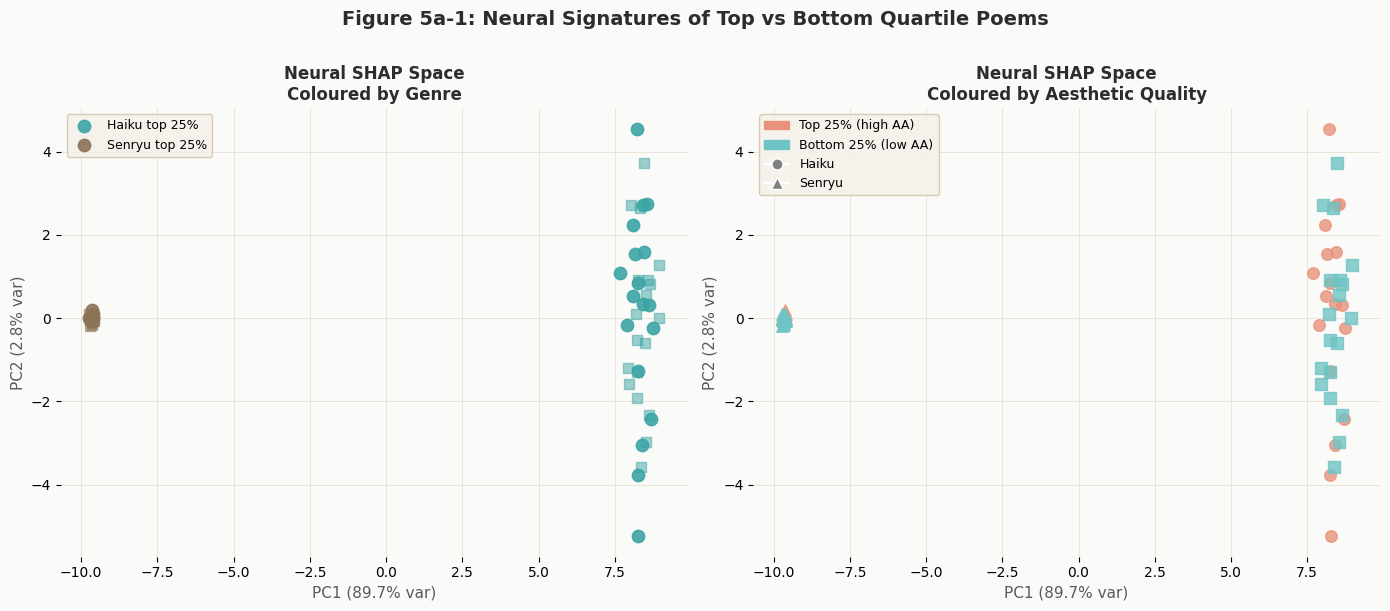

In [38]:
# ── Figure: 2D SHAP space coloured by genre + quartile ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

markers = {'top': 'o', 'bottom': 's'}
colors  = {'Haiku': TEAL_BASE, 'Senryu': SAND_DARK}
alphas  = {'top': 0.9, 'bottom': 0.5}
sizes   = {'top': 80, 'bottom': 60}

# Left: coloured by Genre
for genre in ['Haiku', 'Senryu']:
    for q in ['top', 'bottom']:
        sub = extreme[(extreme['Genre'] == genre) & (extreme['quartile'] == q)]
        axes[0].scatter(sub['PC1'], sub['PC2'],
                        c=colors[genre], marker=markers[q],
                        alpha=alphas[q], s=sizes[q], zorder=3,
                        label=f'{genre} {q} 25%' if q == 'top' else None)

axes[0].set_facecolor(BG)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=11, color=TEXT_MED)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=11, color=TEXT_MED)
axes[0].set_title('Neural SHAP Space\nColoured by Genre', fontsize=12, fontweight='bold', color=TEXT_DARK)
axes[0].legend(fontsize=9, framealpha=0.85, facecolor=SAND_PALE, edgecolor=SAND_BASE)
for sp in axes[0].spines.values(): sp.set_visible(False)
axes[0].grid(True, color=SAND_BASE, alpha=0.4, linewidth=0.7)

# Right: coloured by Quartile
qcolors = {'top': CORAL_BASE, 'bottom': TEAL_LIGHT}
for genre in ['Haiku', 'Senryu']:
    for q in ['top', 'bottom']:
        sub = extreme[(extreme['Genre'] == genre) & (extreme['quartile'] == q)]
        axes[1].scatter(sub['PC1'], sub['PC2'],
                        c=qcolors[q], marker=markers[q] if genre == 'Haiku' else '^',
                        alpha=0.8, s=70, zorder=3)

# Add legend manually
legend_elements = [
    mpatches.Patch(color=CORAL_BASE, label='Top 25% (high AA)'),
    mpatches.Patch(color=TEAL_LIGHT, label='Bottom 25% (low AA)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Haiku'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='grey', markersize=8, label='Senryu'),
]
axes[1].legend(handles=legend_elements, fontsize=9, framealpha=0.85, facecolor=SAND_PALE, edgecolor=SAND_BASE)
axes[1].set_facecolor(BG)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=11, color=TEXT_MED)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=11, color=TEXT_MED)
axes[1].set_title('Neural SHAP Space\nColoured by Aesthetic Quality', fontsize=12, fontweight='bold', color=TEXT_DARK)
for sp in axes[1].spines.values(): sp.set_visible(False)
axes[1].grid(True, color=SAND_BASE, alpha=0.4, linewidth=0.7)

fig.suptitle('Figure 5a-1: Neural Signatures of Top vs Bottom Quartile Poems',
             fontsize=14, fontweight='bold', color=TEXT_DARK, y=1.01)
plt.tight_layout()
plt.savefig('fig_5a1_quartile_neural_space.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Analysis 2: Rating-Profile Clustering

Cluster 139 poems (Haiku + Senryu) by their 5D mean rating vectors.
Test whether resulting clusters align with genre labels or cut across them.

Best k by silhouette: 2


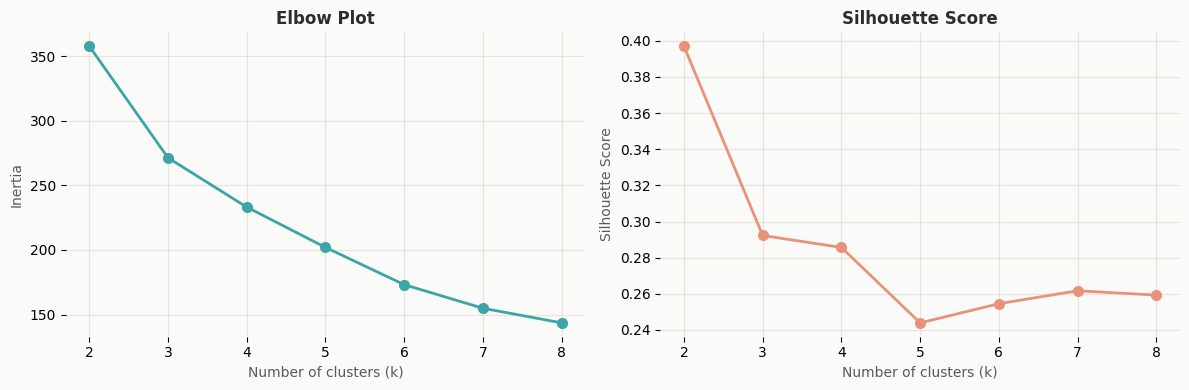

In [39]:
# ── Determine optimal number of clusters ──────────────────────────────────────
X_ratings = poem_ratings_poetry[RATING_COLS].values
X_ratings_scaled = StandardScaler().fit_transform(X_ratings)

inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_ratings_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_ratings_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
for ax in axes: ax.set_facecolor(BG)

axes[0].plot(list(K_range), inertias, color=TEAL_BASE, lw=2, marker='o', markersize=7)
axes[0].set_xlabel('Number of clusters (k)', color=TEXT_MED)
axes[0].set_ylabel('Inertia', color=TEXT_MED)
axes[0].set_title('Elbow Plot', fontweight='bold', color=TEXT_DARK)
for sp in axes[0].spines.values(): sp.set_visible(False)
axes[0].grid(True, color=SAND_BASE, alpha=0.4)

axes[1].plot(list(K_range), silhouettes, color=CORAL_BASE, lw=2, marker='o', markersize=7)
axes[1].set_xlabel('Number of clusters (k)', color=TEXT_MED)
axes[1].set_ylabel('Silhouette Score', color=TEXT_MED)
axes[1].set_title('Silhouette Score', fontweight='bold', color=TEXT_DARK)
for sp in axes[1].spines.values(): sp.set_visible(False)
axes[1].grid(True, color=SAND_BASE, alpha=0.4)

best_k = list(K_range)[np.argmax(silhouettes)]
print(f'Best k by silhouette: {best_k}')
plt.tight_layout()
plt.savefig('fig_5a2a_cluster_selection.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [40]:
# ── Fit final clustering ───────────────────────────────────────────────────────
# Use best_k from silhouette; also try k=2 (theory-driven: emotion vs nature)
K_FINAL = best_k  # change to 2 if theory-driven preferred

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
poem_ratings_poetry['cluster'] = km_final.fit_predict(X_ratings_scaled)

# How well do clusters align with genre?
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
genre_labels = (poem_ratings_poetry['Genre'] == 'Haiku').astype(int).values
cluster_labels = poem_ratings_poetry['cluster'].values

ari = adjusted_rand_score(genre_labels, cluster_labels)
nmi = normalized_mutual_info_score(genre_labels, cluster_labels)

print(f'Adjusted Rand Index (cluster vs genre): {ari:.3f}')
print(f'  ARI=1.0: clusters perfectly align with genre labels')
print(f'  ARI~0:   clusters are independent of genre')
print(f'Normalised Mutual Information: {nmi:.3f}')

# Cross-tabulation
print('\nCluster × Genre cross-tabulation:')
print(pd.crosstab(poem_ratings_poetry['cluster'], poem_ratings_poetry['Genre']))

Adjusted Rand Index (cluster vs genre): 0.000
  ARI=1.0: clusters perfectly align with genre labels
  ARI~0:   clusters are independent of genre
Normalised Mutual Information: 0.005

Cluster × Genre cross-tabulation:
Genre    Haiku  Senryu
cluster               
0           39      33
1           31      37


In [41]:
# ── Test neural separation: do SHAP vectors separate by rating cluster? ────────
# Merge cluster labels into poem SHAP
poem_shap_clustered = poem_shap_collapsed.merge(
    poem_ratings_poetry[['poem_id', 'Genre', 'cluster', 'AA']],
    on=['poem_id', 'Genre'], how='left'
)

# PCA on SHAP vectors to visualise cluster separation
X_shap_all = poem_shap_clustered[feature_cols].values
X_shap_scaled = StandardScaler().fit_transform(X_shap_all)
pca2 = PCA(n_components=2, random_state=42)
pcs2 = pca2.fit_transform(X_shap_scaled)
poem_shap_clustered['SHAP_PC1'] = pcs2[:, 0]
poem_shap_clustered['SHAP_PC2'] = pcs2[:, 1]

# LDA: how well do rating clusters separate in neural space?
valid = poem_shap_clustered.dropna(subset=['cluster'])
lda = LinearDiscriminantAnalysis()
lda_scores = []
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lda_cv = cross_val_score(lda, 
                          valid[feature_cols].values, 
                          valid['cluster'].values,
                          cv=cv, scoring='accuracy')
print(f'LDA cross-validated accuracy (neural → rating cluster): {lda_cv.mean():.3f} ± {lda_cv.std():.3f}')
print(f'  Chance level: {1/K_FINAL:.3f}')

# Repeat for genre labels
lda_genre = cross_val_score(lda,
                             valid[feature_cols].values,
                             (valid['Genre']=='Haiku').astype(int).values,
                             cv=cv, scoring='accuracy')
print(f'\nLDA cross-validated accuracy (neural → genre): {lda_genre.mean():.3f} ± {lda_genre.std():.3f}')
print(f'  If neural → rating cluster > neural → genre: content dominates label')
print(f'  If neural → genre > neural → rating cluster: genre label dominates')

LDA cross-validated accuracy (neural → rating cluster): 0.521 ± 0.066
  Chance level: 0.500

LDA cross-validated accuracy (neural → genre): 1.000 ± 0.000
  If neural → rating cluster > neural → genre: content dominates label
  If neural → genre > neural → rating cluster: genre label dominates


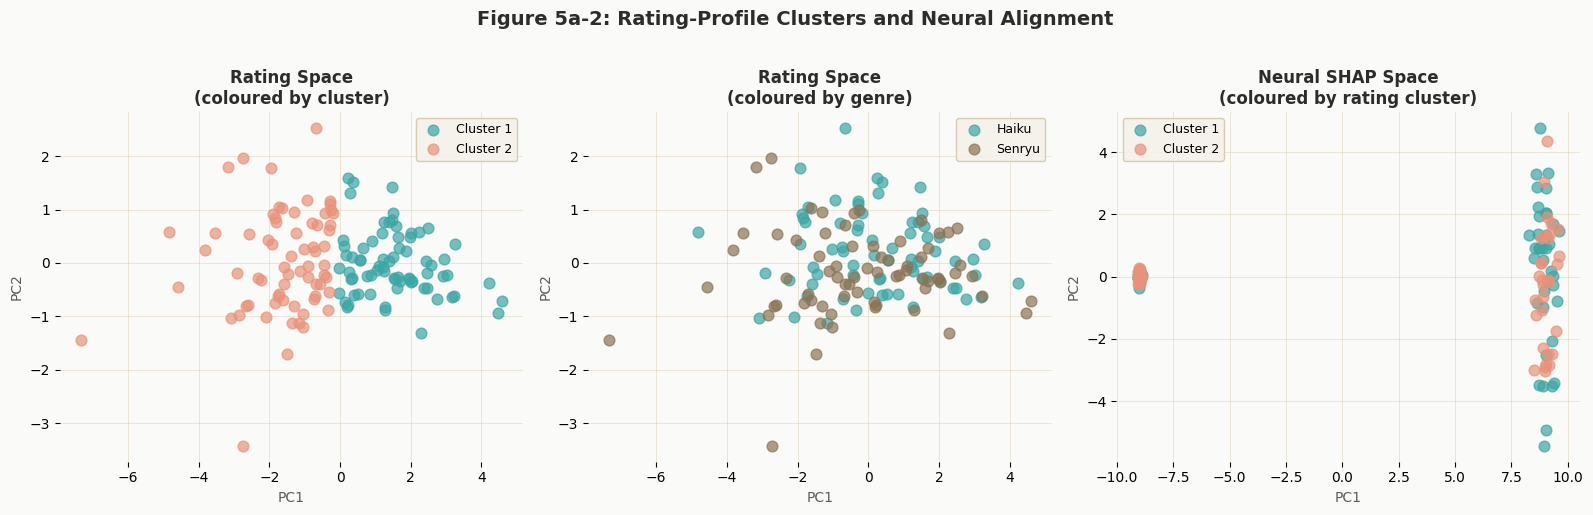

In [42]:
# ── Figure: Clustering results ─────────────────────────────────────────────────
cluster_palette = [TEAL_BASE, CORAL_BASE, SAND_DARK, TEAL_DARK, SAND_MED]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

# Panel A: Rating PCA space coloured by cluster
rating_pca = PCA(n_components=2, random_state=42)
rating_pcs = rating_pca.fit_transform(X_ratings_scaled)
poem_ratings_poetry['R_PC1'] = rating_pcs[:, 0]
poem_ratings_poetry['R_PC2'] = rating_pcs[:, 1]

for c in range(K_FINAL):
    sub = poem_ratings_poetry[poem_ratings_poetry['cluster'] == c]
    axes[0].scatter(sub['R_PC1'], sub['R_PC2'], c=cluster_palette[c],
                    alpha=0.7, s=60, label=f'Cluster {c+1}', zorder=3)
axes[0].set_title('Rating Space\n(coloured by cluster)', fontweight='bold', color=TEXT_DARK)
axes[0].legend(fontsize=9, facecolor=SAND_PALE, edgecolor=SAND_BASE, framealpha=0.85)

# Panel B: Rating PCA space coloured by genre
for genre, col in STIM_COLORS.items():
    sub = poem_ratings_poetry[poem_ratings_poetry['Genre'] == genre]
    axes[1].scatter(sub['R_PC1'], sub['R_PC2'], c=col, alpha=0.7, s=60, label=genre, zorder=3)
axes[1].set_title('Rating Space\n(coloured by genre)', fontweight='bold', color=TEXT_DARK)
axes[1].legend(fontsize=9, facecolor=SAND_PALE, edgecolor=SAND_BASE, framealpha=0.85)

# Panel C: Neural SHAP PCA space coloured by rating cluster
for c in range(K_FINAL):
    sub = poem_shap_clustered[poem_shap_clustered['cluster'] == c]
    axes[2].scatter(sub['SHAP_PC1'], sub['SHAP_PC2'], c=cluster_palette[c],
                    alpha=0.7, s=60, label=f'Cluster {c+1}', zorder=3)
axes[2].set_title('Neural SHAP Space\n(coloured by rating cluster)', fontweight='bold', color=TEXT_DARK)
axes[2].legend(fontsize=9, facecolor=SAND_PALE, edgecolor=SAND_BASE, framealpha=0.85)

for ax in axes:
    ax.set_facecolor(BG)
    ax.set_xlabel('PC1', color=TEXT_MED, fontsize=10)
    ax.set_ylabel('PC2', color=TEXT_MED, fontsize=10)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.grid(True, color=SAND_BASE, alpha=0.4, linewidth=0.7)

fig.suptitle('Figure 5a-2: Rating-Profile Clusters and Neural Alignment',
             fontsize=14, fontweight='bold', color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig('fig_5a2_clustering.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 6. Analysis 3: Representational Similarity Analysis (RSA)

Do neural responses track the evaluative structure of poems, not just their genre label?
1. Rating similarity matrix (139 × 139 poems)
2. Neural SHAP similarity matrix (139 × 139 poems)
3. Mantel test: do the two structures correlate?

In [43]:
# ── Build similarity matrices ──────────────────────────────────────────────────
# Align poems: use only poems present in both ratings and SHAP tables
common_poems = sorted(
    set(poem_ratings_poetry['poem_id']) & set(poem_shap_collapsed['poem_id'])
)
print(f'Poems in both tables: {len(common_poems)}')

ratings_aligned = (
    poem_ratings_poetry
    .set_index('poem_id')
    .loc[common_poems, RATING_COLS]
    .values
)

shap_aligned = (
    poem_shap_collapsed
    .set_index('poem_id')
    .loc[common_poems, feature_cols]
    .values
)

# Cosine distance → similarity
RDM_ratings = squareform(pdist(ratings_aligned, metric='cosine'))   # Rating dissimilarity
RDM_neural  = squareform(pdist(shap_aligned,  metric='cosine'))     # Neural dissimilarity

print(f'Rating RDM shape:  {RDM_ratings.shape}')
print(f'Neural RDM shape:  {RDM_neural.shape}')

Poems in both tables: 140
Rating RDM shape:  (140, 140)
Neural RDM shape:  (140, 140)


In [44]:
# ── Mantel test (permutation-based) ───────────────────────────────────────────
def mantel_test(rdm1, rdm2, n_permutations=10000, random_state=42):
    """Mantel test: correlation between two RDMs using upper triangle."""
    np.random.seed(random_state)
    n = rdm1.shape[0]
    
    # Extract upper triangle
    idx = np.triu_indices(n, k=1)
    v1 = rdm1[idx]
    v2 = rdm2[idx]
    
    # Observed correlation
    r_obs, _ = spearmanr(v1, v2)
    
    # Permutation distribution: permute rows/columns of rdm2 together
    r_null = []
    for _ in range(n_permutations):
        perm = np.random.permutation(n)
        rdm2_perm = rdm2[perm][:, perm]
        r_p, _ = spearmanr(v1, rdm2_perm[idx])
        r_null.append(r_p)
    
    p_val = np.mean(np.abs(r_null) >= np.abs(r_obs))
    return r_obs, p_val, np.array(r_null)

print('Running Mantel test (10,000 permutations)...')
r_mantel, p_mantel, null_dist = mantel_test(RDM_ratings, RDM_neural)
print(f'\nMantel r = {r_mantel:.4f}, p = {p_mantel:.4f}')
print(f'Interpretation:')
if p_mantel < 0.05:
    print(f'  Significant: neural responses track evaluative structure (r={r_mantel:.3f})')
    print(f'  This supports content-specialised processing, not just genre labelling')
else:
    print(f'  Non-significant: neural and rating structures are independent')

Running Mantel test (10,000 permutations)...

Mantel r = 0.0836, p = 0.0000
Interpretation:
  Significant: neural responses track evaluative structure (r=0.084)
  This supports content-specialised processing, not just genre labelling


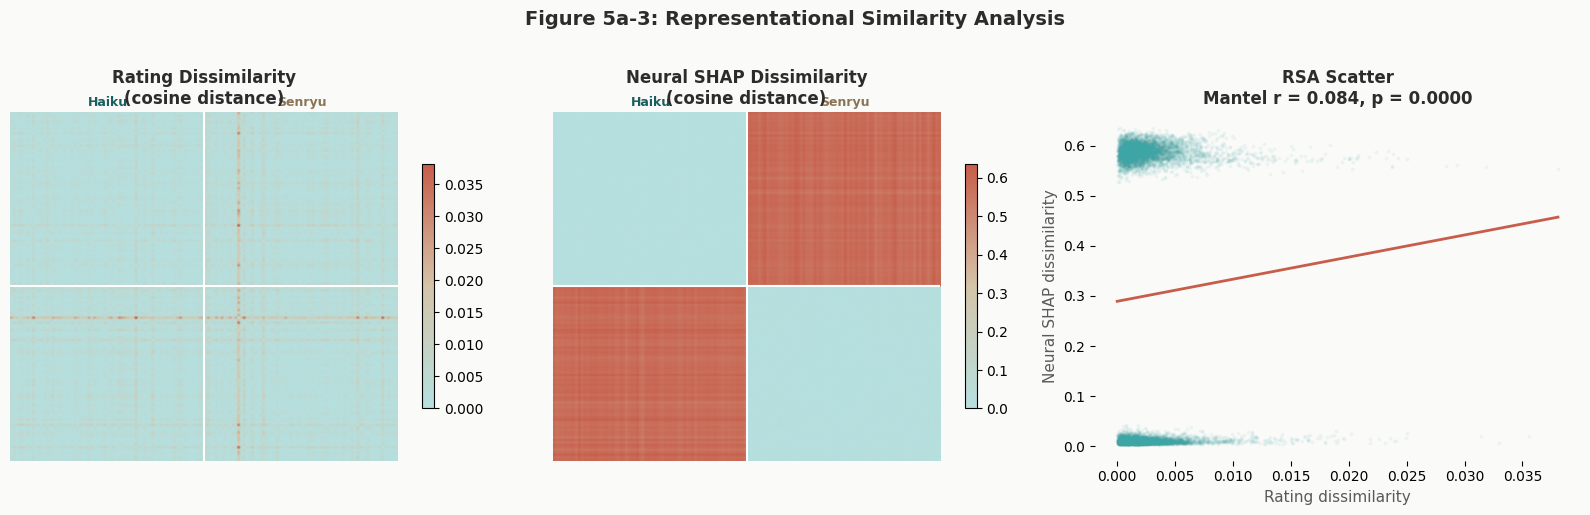

In [45]:
# ── Figure: RSA ────────────────────────────────────────────────────────────────
# Genre order: Haiku first, then Senryu
genre_order = [
    p for p in common_poems 
    if poem_ratings_poetry.set_index('poem_id').loc[p, 'Genre'] == 'Haiku'
] + [
    p for p in common_poems 
    if poem_ratings_poetry.set_index('poem_id').loc[p, 'Genre'] == 'Senryu'
]
genre_sort_idx = [common_poems.index(p) for p in genre_order]

from matplotlib.colors import LinearSegmentedColormap
cmap_rdm = LinearSegmentedColormap.from_list('rdm', [TEAL_PALE, SAND_BASE, CORAL_DARK], N=256)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

# Rating RDM
rdm_sorted = RDM_ratings[np.ix_(genre_sort_idx, genre_sort_idx)]
im0 = axes[0].imshow(rdm_sorted, aspect='auto', cmap=cmap_rdm)
axes[0].set_title('Rating Dissimilarity\n(cosine distance)', fontweight='bold', color=TEXT_DARK)
n_haiku = sum(1 for p in common_poems 
               if poem_ratings_poetry.set_index('poem_id').loc[p, 'Genre'] == 'Haiku')
axes[0].axhline(n_haiku - 0.5, color='white', lw=1.5)
axes[0].axvline(n_haiku - 0.5, color='white', lw=1.5)
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].text(n_haiku/2, -3, 'Haiku', ha='center', color=TEAL_DARK, fontweight='bold', fontsize=9)
axes[0].text(n_haiku + (len(common_poems)-n_haiku)/2, -3, 'Senryu',
             ha='center', color=SAND_DARK, fontweight='bold', fontsize=9)
plt.colorbar(im0, ax=axes[0], shrink=0.7)

# Neural RDM
rdm_neural_sorted = RDM_neural[np.ix_(genre_sort_idx, genre_sort_idx)]
im1 = axes[1].imshow(rdm_neural_sorted, aspect='auto', cmap=cmap_rdm)
axes[1].set_title('Neural SHAP Dissimilarity\n(cosine distance)', fontweight='bold', color=TEXT_DARK)
axes[1].axhline(n_haiku - 0.5, color='white', lw=1.5)
axes[1].axvline(n_haiku - 0.5, color='white', lw=1.5)
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].text(n_haiku/2, -3, 'Haiku', ha='center', color=TEAL_DARK, fontweight='bold', fontsize=9)
axes[1].text(n_haiku + (len(common_poems)-n_haiku)/2, -3, 'Senryu',
             ha='center', color=SAND_DARK, fontweight='bold', fontsize=9)
plt.colorbar(im1, ax=axes[1], shrink=0.7)

# Scatter: rating vs neural dissimilarity
idx = np.triu_indices(len(common_poems), k=1)
axes[2].scatter(RDM_ratings[idx], RDM_neural[idx],
                alpha=0.05, s=3, color=TEAL_BASE, rasterized=True)
axes[2].set_xlabel('Rating dissimilarity', color=TEXT_MED, fontsize=11)
axes[2].set_ylabel('Neural SHAP dissimilarity', color=TEXT_MED, fontsize=11)
axes[2].set_title(f'RSA Scatter\nMantel r = {r_mantel:.3f}, p = {p_mantel:.4f}',
                  fontweight='bold', color=TEXT_DARK)

# Add trend line
m, b = np.polyfit(RDM_ratings[idx], RDM_neural[idx], 1)
xline = np.linspace(RDM_ratings[idx].min(), RDM_ratings[idx].max(), 100)
axes[2].plot(xline, m*xline + b, color=CORAL_DARK, lw=2)

for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle('Figure 5a-3: Representational Similarity Analysis',
             fontsize=14, fontweight='bold', color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig('fig_5a3_RSA.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

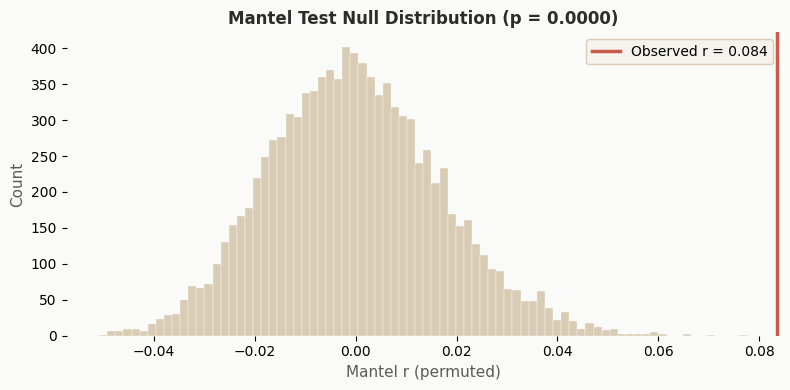

In [46]:
# ── Null distribution plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor(BG)
ax.hist(null_dist, bins=80, color=SAND_BASE, edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(r_mantel, color=CORAL_DARK, lw=2.5, label=f'Observed r = {r_mantel:.3f}')
ax.set_xlabel('Mantel r (permuted)', color=TEXT_MED, fontsize=11)
ax.set_ylabel('Count', color=TEXT_MED, fontsize=11)
ax.set_title(f'Mantel Test Null Distribution (p = {p_mantel:.4f})',
             fontweight='bold', color=TEXT_DARK)
ax.legend(fontsize=10, facecolor=SAND_PALE, edgecolor=SAND_BASE)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_5a3_RSA_null.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 7. Summary of 5a Results

In [47]:
print('=' * 60)
print('QUESTION 5a SUMMARY')
print('=' * 60)
print('\n[1] Top/Bottom Quartile Comparison')
print(f'    Top Haiku vs Top Senryu (PC1): p = {p:.4f}')
print(f'    → {"Convergence: aesthetic quality dominates genre" if p > 0.05 else "Divergence: genre persists even at matched quality"}')

print(f'\n[2] Rating-Profile Clustering (k={K_FINAL})')
print(f'    ARI (cluster vs genre) = {ari:.3f}')
print(f'    LDA accuracy (neural → rating cluster) = {lda_cv.mean():.3f} ± {lda_cv.std():.3f}')
print(f'    LDA accuracy (neural → genre label)    = {lda_genre.mean():.3f} ± {lda_genre.std():.3f}')
print(f'    → {"Content structure (rating cluster) > genre label in neural space" if lda_cv.mean() > lda_genre.mean() else "Genre label > content structure in neural space"}')

print(f'\n[3] RSA (Mantel test)')
print(f'    r = {r_mantel:.4f}, p = {p_mantel:.4f}')
print(f'    → {"Neural responses track evaluative structure" if p_mantel < 0.05 else "Neural and evaluative structures are independent"}')

QUESTION 5a SUMMARY

[1] Top/Bottom Quartile Comparison
    Top Haiku vs Top Senryu (PC1): p = 0.0000
    → Divergence: genre persists even at matched quality

[2] Rating-Profile Clustering (k=2)
    ARI (cluster vs genre) = 0.000
    LDA accuracy (neural → rating cluster) = 0.521 ± 0.066
    LDA accuracy (neural → genre label)    = 1.000 ± 0.000
    → Genre label > content structure in neural space

[3] RSA (Mantel test)
    r = 0.0836, p = 0.0000
    → Neural responses track evaluative structure
